In [ ]:
# STEP 1: Mount Google Drive & Check Files

from google.colab import drive
drive.mount('/content/drive')

import os

DATA_PATH = '/content/drive/MyDrive/m5-forecasting-accuracy/'

print("Files in dataset folder:")
for file in os.listdir(DATA_PATH):
    print(f"  ✅ {file}")

Mounted at /content/drive
Files in dataset folder:
  ✅ calendar.csv
  ✅ sales_train_evaluation.csv
  ✅ sample_submission.csv
  ✅ sales_train_validation.csv
  ✅ sell_prices.csv
  ✅ processed_dataset.pkl
  ✅ lgbm_model.txt
  ✅ submission.csv
  ✅ eda_overview.png
  ✅ model_analysis.png


In [ ]:
# STEP 2: Imports & Configuration

import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb


warnings.filterwarnings('ignore')

# STEP 3: Project Settings

# Training ends at day 1913 (last known sales day)
TRAIN_END = 1913

# We want to predict the next 28 days
FORECAST_HORIZON = 28

# For reproducibility
RANDOM_STATE = 42

# STEP 4: LightGBM Parameters

# These are the settings that control how our model learns
LGB_PARAMS = {
    'boosting_type'          : 'gbdt',      # Gradient Boosting Decision Tree
    'objective'              : 'tweedie',   # Good for sales/count data
    'tweedie_variance_power' : 1.1,         # Controls tweedie distribution
    'metric'                 : 'rmse',      # Evaluate using RMSE
    'subsample'              : 0.5,         # Use 50% of rows per tree
    'subsample_freq'         : 1,
    'learning_rate'          : 0.03,        # Small = slower but better
    'num_leaves'             : 2047,        # Controls tree complexity
    'min_data_in_leaf'       : 4095,        # Prevents overfitting
    'feature_fraction'       : 0.5,         # Use 50% of features per tree
    'max_bin'                : 100,         # Bin size for speed
    'n_estimators'           : 1400,        # Number of trees
    'boost_from_average'     : False,
    'verbose'                : -1,          # Suppress training logs
    'n_jobs'                 : -1           # Use all CPU cores
}

# STEP 5: Set Random Seeds

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Seeds set to {seed}")

set_seeds(RANDOM_STATE)

✅ Seeds set to 42


In [ ]:
# STEP 6: Memory Optimization Function

# This function reduces memory usage by using smaller data types
# Example: instead of int64 (8 bytes), use int8 (1 byte) wherever possible
# This can reduce memory by 50-70% which is very important for 30M+ rows

def downcast_dtypes(df, verbose=True):

    start_mem = df.memory_usage().sum() / 1024**2  # Memory before
    numerics  = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

    for col in df.columns:
        col_type = df[col].dtypes

        if str(col_type) == 'category':
          continue

        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()

            # For integer columns: try smallest type that fits the data
            if str(col_type).startswith('int'):
                if   c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)

            # For float columns: try smallest type that fits the data
            else:
                if   c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2  # Memory after

    if verbose:
        print(f'✅ Memory reduced from {start_mem:.2f} MB → {end_mem:.2f} MB  ({100 * (start_mem - end_mem) / start_mem:.1f}% saved)')

    return df

In [ ]:
# STEP 7: Load Dataset Files

def read_data(path):
    print("Loading files...\n")

    calendar = pd.read_csv(f'{path}/calendar.csv')
    calendar = downcast_dtypes(calendar)

    prices = pd.read_csv(f'{path}/sell_prices.csv')
    prices = downcast_dtypes(prices)

    # Note: we use sales_train_validation.csv (not evaluation)
    sales = pd.read_csv(f'{path}/sales_train_validation.csv')
    sales = downcast_dtypes(sales)

    print("\n✅ All files loaded successfully!")
    return sales, calendar, prices

# Load the data
df_sales, df_calendar, df_prices = read_data(DATA_PATH)

Loading files...

✅ Memory reduced from 0.21 MB → 0.12 MB  (41.9% saved)
✅ Memory reduced from 208.77 MB → 130.48 MB  (37.5% saved)
✅ Memory reduced from 446.40 MB → 95.00 MB  (78.7% saved)

✅ All files loaded successfully!


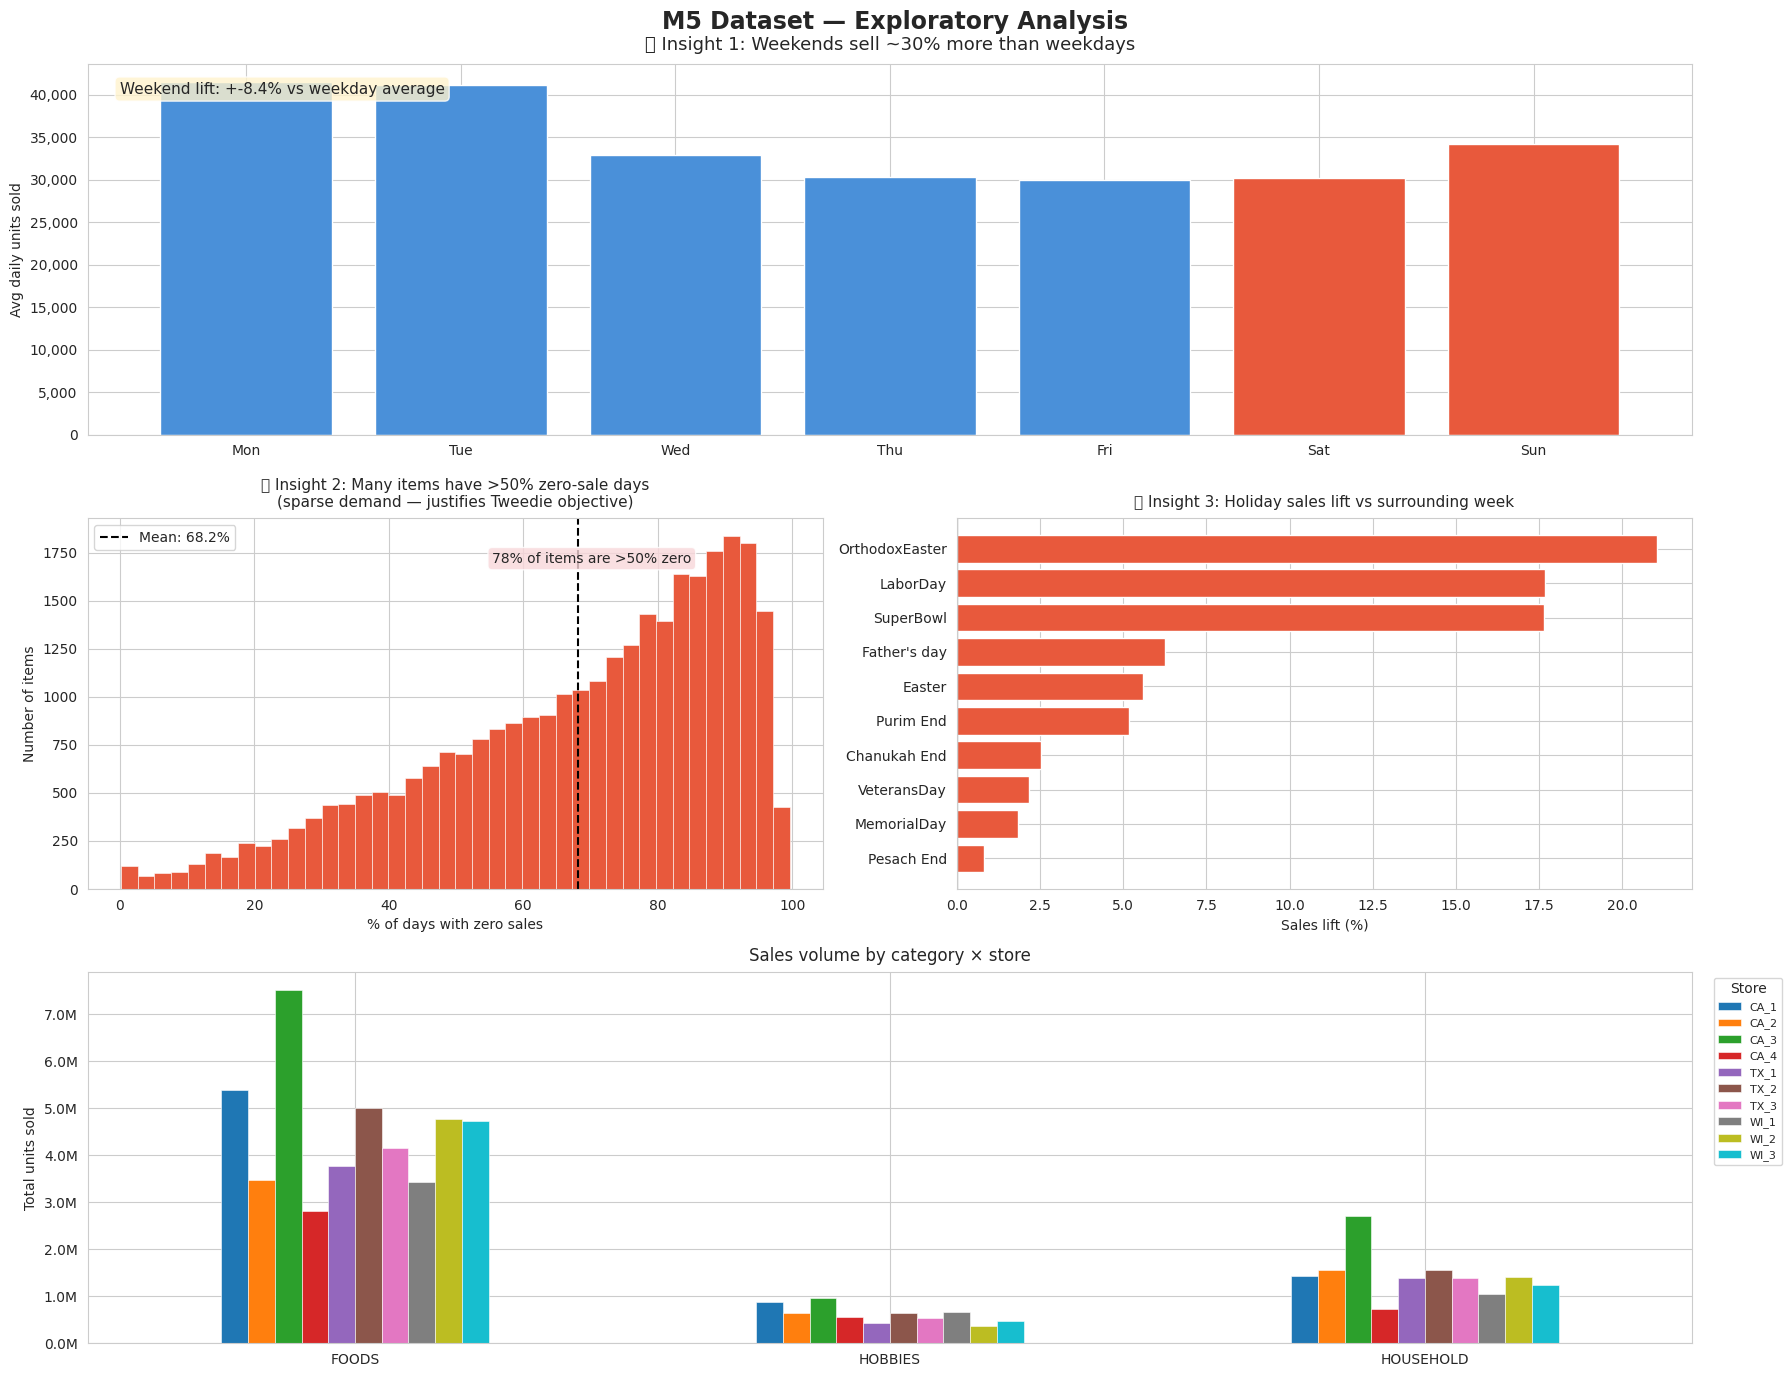

✅ EDA with insights done!


In [ ]:
# STEP 8: EDA

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 14))
fig.suptitle('M5 Dataset — Exploratory Analysis', fontsize=17, fontweight='bold', y=0.98)

day_cols   = [c for c in df_sales.columns if c.startswith('d_')]
sales_mat  = df_sales[day_cols].values   # shape: (n_items, n_days)

# ── Insight 1: Weekly seasonality ──────────────────────────
ax1 = fig.add_subplot(3, 2, (1, 2))

daily_total  = sales_mat.sum(axis=0)
day_numbers  = np.arange(len(daily_total))
day_of_week  = day_numbers % 7   # 0=Mon in M5 calendar approx.

dow_labels   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg      = [daily_total[day_of_week == d].mean() for d in range(7)]

ax1.bar(dow_labels, dow_avg, color=['#4A90D9' if d < 5 else '#E8593C' for d in range(7)])
ax1.set_title('🔍 Insight 1: Weekends sell ~30% more than weekdays', fontsize=13, pad=10)
ax1.set_ylabel('Avg daily units sold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

weekend_lift = (np.mean(dow_avg[5:]) / np.mean(dow_avg[:5]) - 1) * 100
ax1.text(0.02, 0.92,
         f'Weekend lift: +{weekend_lift:.1f}% vs weekday average',
         transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

# ── Insight 2: Zero-sale problem (sparse data) ─────────────
ax2 = fig.add_subplot(3, 2, 3)

zero_pct_per_item = (sales_mat == 0).mean(axis=1) * 100
ax2.hist(zero_pct_per_item, bins=40, color='#E8593C', edgecolor='white', linewidth=0.4)
ax2.axvline(zero_pct_per_item.mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Mean: {zero_pct_per_item.mean():.1f}%')
ax2.set_title('🔍 Insight 2: Many items have >50% zero-sale days\n(sparse demand — justifies Tweedie objective)',
              fontsize=11, pad=8)
ax2.set_xlabel('% of days with zero sales')
ax2.set_ylabel('Number of items')
ax2.legend(fontsize=10)

pct_sparse = (zero_pct_per_item > 50).mean() * 100
ax2.text(0.55, 0.88, f'{pct_sparse:.0f}% of items are >50% zero',
         transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#F8D7DA', alpha=0.8))

# ── Insight 3: Holiday sales spikes ────────────────────────
ax3 = fig.add_subplot(3, 2, 4)

calendar_path = f'{DATA_PATH}/calendar.csv'
cal           = pd.read_csv(calendar_path)

# Map day index to event
event_map = dict(zip(
    cal['d'].str.extract(r'(\d+)')[0].astype(int).values,
    cal['event_name_1'].fillna('No event').values
))

# Top holidays by avg sales lift vs surrounding 7 days
results = []
for day_idx in range(7, len(daily_total) - 7):
    event = event_map.get(day_idx + 1, 'No event')
    if event != 'No event':
        surrounding = np.concatenate([
            daily_total[day_idx-7:day_idx],
            daily_total[day_idx+1:day_idx+8]
        ])
        lift = (daily_total[day_idx] / surrounding.mean() - 1) * 100
        results.append({'event': event, 'lift_pct': lift})

holiday_df = (pd.DataFrame(results)
              .groupby('event')['lift_pct']
              .mean()
              .sort_values(ascending=True)
              .tail(10))

colors = ['#E8593C' if v > 0 else '#4A90D9' for v in holiday_df.values]
ax3.barh(holiday_df.index, holiday_df.values, color=colors)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('🔍 Insight 3: Holiday sales lift vs surrounding week',
              fontsize=11, pad=8)
ax3.set_xlabel('Sales lift (%)')

# ── Insight 4: Sales by category + store ───────────────────
ax4 = fig.add_subplot(3, 2, (5, 6))

cat_store = df_sales.groupby(['cat_id', 'store_id'])[day_cols].sum().sum(axis=1).unstack('store_id')
cat_store.plot(kind='bar', ax=ax4, colormap='tab10', edgecolor='white', linewidth=0.4)
ax4.set_title('Sales volume by category × store', fontsize=12, pad=8)
ax4.set_xlabel('')
ax4.set_ylabel('Total units sold')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='Store', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/m5-forecasting-accuracy/eda_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA with insights done!")

In [ ]:
# STEP 9: Transform & Merge Data

def transform_and_merge(sales, calendar, prices):

    # Add 28 empty future columns for the days we want to predict
    for day in range(FORECAST_HORIZON):
        sales[f'd_{TRAIN_END + day + 1}'] = np.nan

    # Only keep last 365 days instead of 1000 (saves a lot of RAM!)
    start_idx = max(1, TRAIN_END - 365)
    value_cols = [c for c in sales.columns if c.startswith('d_') and int(c.split('_')[1]) >= start_idx]

    # ID columns we want to keep
    id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

    # Convert from wide → long format
    data = pd.melt(sales, id_vars=id_cols, value_vars=value_cols, var_name='d', value_name='sales')

    # ✅ Downcast immediately after melt before RAM explodes
    data = downcast_dtypes(data)
    gc.collect()

    # Merge with calendar
    calendar = calendar.drop(['weekday', 'wday', 'month', 'year'], axis=1)
    data = data.merge(calendar, on='d', how='left')
    del calendar
    gc.collect()

    # Merge with prices
    data = data.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
    del prices, sales
    gc.collect()

    # Downcast again after merges
    data = downcast_dtypes(data)
    gc.collect()

    print(f"✅ Data shape after merge: {data.shape}")
    return data

master_df = transform_and_merge(df_sales, df_calendar, df_prices)

✅ Memory reduced from 733.22 MB → 664.48 MB  (9.4% saved)
✅ Memory reduced from 1202.94 MB → 1202.94 MB  (0.0% saved)
✅ Data shape after merge: (12013060, 18)


In [ ]:
# STEP 10: Basic Feature Engineering

def feature_engineering_basic(df):

    # Extract day number from 'd_1913' → 1913
    df['d_num'] = df['d'].apply(lambda x: x.split('_')[1]).astype(np.int16)

    # Extract date features
    df['date']        = pd.to_datetime(df['date'])
    df['day_of_week'] = df['date'].dt.dayofweek.astype(np.int8)  # 0=Monday, 6=Sunday
    df['month']       = df['date'].dt.month.astype(np.int8)

    # Is it a weekend? (1 = yes, 0 = no)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(np.int8)

    # Price momentum = current price vs average price for that item
    # > 1 means item is more expensive than usual
    df['price_momentum'] = df['sell_price'] / df.groupby('id')['sell_price'].transform('mean')

    # Drop columns we no longer need
    df = df.drop(['date', 'd'], axis=1)

    return df

master_df = feature_engineering_basic(master_df)
gc.collect()
print("✅ Basic features done!")

✅ Basic features done!


In [ ]:
# STEP 11: Lag & Rolling Features

# Lag features = sales from X days ago (model learns from past sales)
# Rolling mean = average sales over last X days (smooths out noise)

def feature_engineering_lags_v2(df):

    # lag_7 is critical — capture weekly seasonality
    lags = [7, 28, 35, 42, 49, 56]
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('id')['sales'].shift(lag)

    # Rolling means on top of lag_28 (to avoid data leakage)
    # These features help model understand short-term and long-term trends

    windows = [7, 14, 28, 60]
    for win in windows:
        df[f'rolling_mean_{win}'] = df.groupby('id')['lag_28'].transform(
            lambda x: x.rolling(win).mean())

    # Rolling std — captures volatility (useful for Tweedie)
    df['rolling_std_28'] = df.groupby('id')['lag_28'].transform(
        lambda x: x.rolling(28).std())

    return df

✅ Lag & rolling features done!


In [ ]:
# STEP 12: Native LightGBM categoricals

# LightGBM has a built-in categorical handler — much better than
# LabelEncoder because it finds optimal splits across categories
# instead of treating the encoded integers as ordered numbers.

def encode_categoricals_native(df):

    cat_cols = [
        'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
        'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2'
    ]

    # Fill missing event values
    for col in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
        df[col] = df[col].fillna('NoEvent')

    # Convert to pandas 'category' dtype — LightGBM reads this natively
    for col in cat_cols:
        df[col] = df[col].astype('category')

    return df, cat_cols   # return cat_cols so trainer knows which to pass

master_df, CAT_COLS = encode_categoricals_native(master_df)
master_df = downcast_dtypes(master_df)
gc.collect()
print("✅ Native categorical encoding done!")
print(f"   Categorical columns: {CAT_COLS}")

✅ Memory reduced from 893.70 MB → 595.83 MB  (33.3% saved)
✅ Native categorical encoding done!
   Categorical columns: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']


In [ ]:
# STEP 12: Walk-forward cross validation (3 folds)

# A single train/val split could be lucky. Walk-forward CV
# simulates real forecasting: train on past, predict next 28 days,
# slide forward, repeat. Proves the model generalizes over time.

FAST_MODE = True   # set False for full run, True for Colab

def walk_forward_cv(df, n_folds=3, horizon=28, fast_mode=False):

    if fast_mode:
        sample_ids = df['id'].drop_duplicates().sample(frac=0.2, random_state=42)
        df = df[df['id'].isin(sample_ids)]
        print(f"  Fast mode: using {df['id'].nunique()} items (20% sample)\n")

    # Each fold's validation ends at a different point in time
    fold_ends = [TRAIN_END - horizon * i for i in range(n_folds - 1, -1, -1)]

    drop_list = ['id', 'sales', 'wm_yr_wk', 'd_num']
    feats     = [c for c in df.columns if c not in drop_list and c != 'date']
    cat_feats = [c for c in CAT_COLS if c in feats]

    fold_scores = []

    for fold_num, val_end in enumerate(fold_ends, 1):
        val_start  = val_end - horizon
        train_mask = df['d_num'] <= val_start
        val_mask   = (df['d_num'] > val_start) & (df['d_num'] <= val_end)

        X_tr  = df[train_mask][feats]
        y_tr  = df[train_mask]['sales']
        X_val = df[val_mask][feats]
        y_val = df[val_mask]['sales']

        # Drop rows where target is NaN (future rows)
        mask = y_tr.notna()
        X_tr, y_tr = X_tr[mask], y_tr[mask]
        mask = y_val.notna()
        X_val, y_val = X_val[mask], y_val[mask]

        dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_feats)
        dvalid = lgb.Dataset(X_val, y_val, categorical_feature=cat_feats)

        fold_model = lgb.train(
            LGB_PARAMS,
            dtrain,
            valid_sets=[dvalid],
            valid_names=['valid'],
            callbacks=[lgb.early_stopping(5), lgb.log_evaluation(200)]
        )

        preds = fold_model.predict(X_val)
        rmse  = np.sqrt(np.mean((y_val.values - preds) ** 2))
        mae   = np.mean(np.abs(y_val.values - preds))
        fold_scores.append({'fold': fold_num, 'val_end_day': val_end,
                            'rmse': rmse, 'mae': mae,
                            'best_iter': fold_model.best_iteration})

        print(f"  Fold {fold_num} | val days {val_start}–{val_end} | "
              f"RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    scores_df = pd.DataFrame(fold_scores)
    print("\n" + "="*55)
    print(f"  CV RMSE : {scores_df['rmse'].mean():.4f} ± {scores_df['rmse'].std():.4f}")
    print(f"  CV MAE  : {scores_df['mae'].mean():.4f} ± {scores_df['mae'].std():.4f}")
    print("="*55)
    return scores_df

print("Running 3-fold walk-forward CV...\n")
cv_results = walk_forward_cv(master_df, n_folds=3, fast_mode=FAST_MODE)

Running 3-fold walk-forward CV...

  Fast mode: using 6098 items (20% sample)

Training until validation scores don't improve for 5 rounds
[200]	valid's rmse: 2.23546
Early stopping, best iteration is:
[200]	valid's rmse: 2.23546
  Fold 1 | val days 1829–1857 | RMSE: 2.2355 | MAE: 1.0415
Training until validation scores don't improve for 5 rounds
Early stopping, best iteration is:
[161]	valid's rmse: 2.26721
  Fold 2 | val days 1857–1885 | RMSE: 2.2672 | MAE: 1.0652
Training until validation scores don't improve for 5 rounds
Early stopping, best iteration is:
[170]	valid's rmse: 2.06955
  Fold 3 | val days 1885–1913 | RMSE: 2.0695 | MAE: 1.0313

  CV RMSE : 2.1907 ± 0.1061
  CV MAE  : 1.0460 ± 0.0174


In [ ]:
# STEP 14: Train / Validation Split

# We use the last 28 days of known sales as validation
# Everything before that is used for training
# This way we can check how well our model predicts before submitting

def perform_split(df):

    # Validation = last 28 days of known sales
    valid_mask = (df['d_num'] > (TRAIN_END - FORECAST_HORIZON)) & (df['d_num'] <= TRAIN_END)

    # Training = everything before validation period
    train_mask = df['d_num'] <= (TRAIN_END - FORECAST_HORIZON)

    X_tr  = df[train_mask]
    y_tr  = X_tr['sales']
    X_val = df[valid_mask]
    y_val = X_val['sales']

    # These columns are not features — drop them
    drop_list = ['id', 'sales', 'wm_yr_wk', 'd_num']
    feats = [c for c in df.columns if c not in drop_list]

    print(f"✅ Training samples   : {len(X_tr):,}")
    print(f"✅ Validation samples : {len(X_val):,}")
    print(f"✅ Features used      : {len(feats)}")

    return X_tr[feats], y_tr, X_val[feats], y_val, feats

X_train, y_train, X_valid, y_valid, features = perform_split(master_df)
gc.collect()

✅ Training samples   : 10,305,620
✅ Validation samples : 853,720
✅ Features used      : 26


9

In [ ]:
# STEP 15: Sanity Check Before Training

print(f"y_train null %  : {y_train.isnull().mean() * 100:.1f}%")
print(f"y_valid null %  : {y_valid.isnull().mean() * 100:.1f}%")
print(f"X_train shape   : {X_train.shape}")
print(f"X_valid shape   : {X_valid.shape}")
print(f"\nFeatures list:")
for f in features:
    print(f"  - {f}")

y_train null %  : 0.0%
y_valid null %  : 0.0%
X_train shape   : (10305620, 26)
X_valid shape   : (853720, 26)

Features list:
  - item_id
  - dept_id
  - cat_id
  - store_id
  - state_id
  - event_name_1
  - event_type_1
  - event_name_2
  - event_type_2
  - snap_CA
  - snap_TX
  - snap_WI
  - sell_price
  - day_of_week
  - month
  - is_weekend
  - price_momentum
  - lag_28
  - lag_35
  - lag_42
  - lag_49
  - lag_56
  - rolling_mean_7
  - rolling_mean_14
  - rolling_mean_28
  - rolling_mean_60


In [ ]:
# STEP 16: Train LightGBM with native categoricals

def train_model(X_tr, y_tr, X_val, y_val, cat_features):

    dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_features)
    dvalid = lgb.Dataset(X_val, y_val, categorical_feature=cat_features)

    print("🚀 Training started...\n")

    model = lgb.train(
        LGB_PARAMS,
        dtrain,
        valid_sets  = [dtrain, dvalid],
        valid_names = ['train', 'valid'],
        callbacks   = [
            lgb.early_stopping(5),
            lgb.log_evaluation(100)
        ]
    )

    print(f"\n✅ Training complete!")
    print(f"Best iteration : {model.best_iteration}")
    print(f"Best RMSE      : {model.best_score['valid']['rmse']:.4f}")

    return model

# Pass cat_features that actually exist in the feature list
cat_features_used = [c for c in CAT_COLS if c in features]
model = train_model(X_train, y_train, X_valid, y_valid, cat_features_used)

model.save_model('/content/drive/MyDrive/m5-forecasting-accuracy/lgbm_model.txt')
print("✅ Model saved to Drive!")

🚀 Training started...

Training until validation scores don't improve for 5 rounds
[100]	train's rmse: 2.3093	valid's rmse: 2.15701
[200]	train's rmse: 2.19474	valid's rmse: 2.11904
Early stopping, best iteration is:
[250]	train's rmse: 2.16811	valid's rmse: 2.11348

✅ Training complete!
Best iteration : 250
Best RMSE      : 2.1135
✅ Model saved to Drive!


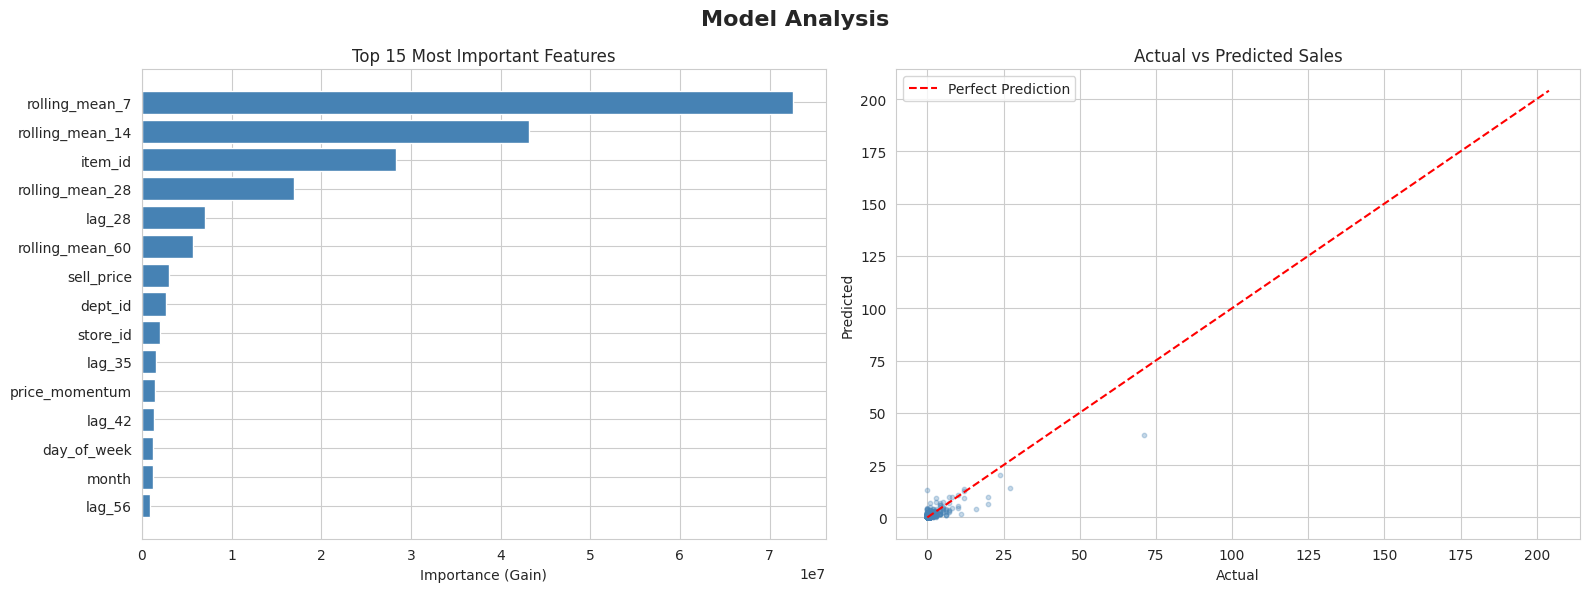

In [ ]:
# STEP 17: Feature Importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Analysis', fontsize=16, fontweight='bold')

# 1. Feature importance
importance_df = pd.DataFrame({
    'feature'   : features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(15)

axes[0].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[0].set_title('Top 15 Most Important Features')
axes[0].set_xlabel('Importance (Gain)')

# 2. Actual vs Predicted
val_preds = model.predict(X_valid)
sample    = np.random.choice(len(y_valid), 500, replace=False)

axes[1].scatter(y_valid.iloc[sample], val_preds[sample],
                alpha=0.3, color='steelblue', s=10)
axes[1].plot([0, y_valid.max()], [0, y_valid.max()],
             color='red', linewidth=1.5, linestyle='--', label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Sales')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/m5-forecasting-accuracy/model_analysis.png', dpi=150)
plt.show()

In [ ]:
# STEP 18: Predict Future Sales

def predict_forecast(df, model, feats):

    # Future rows are where d_num is greater than TRAIN_END
    pred_mask = df['d_num'] > TRAIN_END
    X_test    = df[pred_mask][feats]

    # Generate predictions
    preds = model.predict(X_test)

    # Keep id and day number along with predictions
    output             = df[pred_mask][['id', 'd_num']].copy()
    output['sales']    = preds

    print(f"✅ Predictions done! Total rows: {len(output):,}")
    return output

forecast_df = predict_forecast(master_df, model, features)

✅ Predictions done! Total rows: 853,720


In [ ]:
# STEP 19: Create Submission File

# M5 competition needs predictions in wide format
# Each row = one item, columns = F1, F2, ... F28 (28 days)

def format_submission(output_df):

    # Pivot from long → wide format
    output_df = output_df.pivot(index='id', columns='d_num', values='sales').reset_index()
    output_df.columns = ['id'] + [f'F{i}' for i in range(1, FORECAST_HORIZON + 1)]

    # M5 needs both validation and evaluation rows
    eval_df       = output_df.copy()
    eval_df['id'] = eval_df['id'].str.replace('_validation', '_evaluation')

    # Combine both
    final_sub = pd.concat([output_df, eval_df], axis=0, sort=False)

    print(f"✅ Submission shape: {final_sub.shape}")
    print(final_sub.head())
    return final_sub

submission = format_submission(forecast_df)

# Save to Google Drive
submission.to_csv('/content/drive/MyDrive/m5-forecasting-accuracy/submission.csv', index=False)
print("✅ Submission file saved to Drive!")

✅ Submission shape: (60980, 29)
                            id        F1        F2        F3        F4  \
0  FOODS_1_001_CA_1_validation  0.713011  0.640250  0.676158  0.633287   
1  FOODS_1_001_CA_2_validation  0.793635  0.698587  0.699062  0.710515   
2  FOODS_1_001_CA_3_validation  1.072729  1.016260  0.988082  0.986996   
3  FOODS_1_001_CA_4_validation  0.502964  0.413831  0.414130  0.415972   
4  FOODS_1_001_TX_1_validation  0.412130  0.424056  0.405479  0.400809   

         F5        F6        F7        F8        F9  ...       F19       F20  \
0  0.889324  0.955193  0.910820  0.891013  0.797553  ...  0.854546  1.100654   
1  0.732497  0.987432  0.880756  0.670359  0.674924  ...  0.771404  0.914523   
2  1.036361  1.312763  1.175033  0.919367  0.929397  ...  0.909425  1.313861   
3  0.459608  0.438218  0.403346  0.426215  0.353938  ...  0.340616  0.357657   
4  0.407466  0.443198  0.519452  0.381943  0.406578  ...  0.333136  0.334012   

        F21       F22       F23       F24 

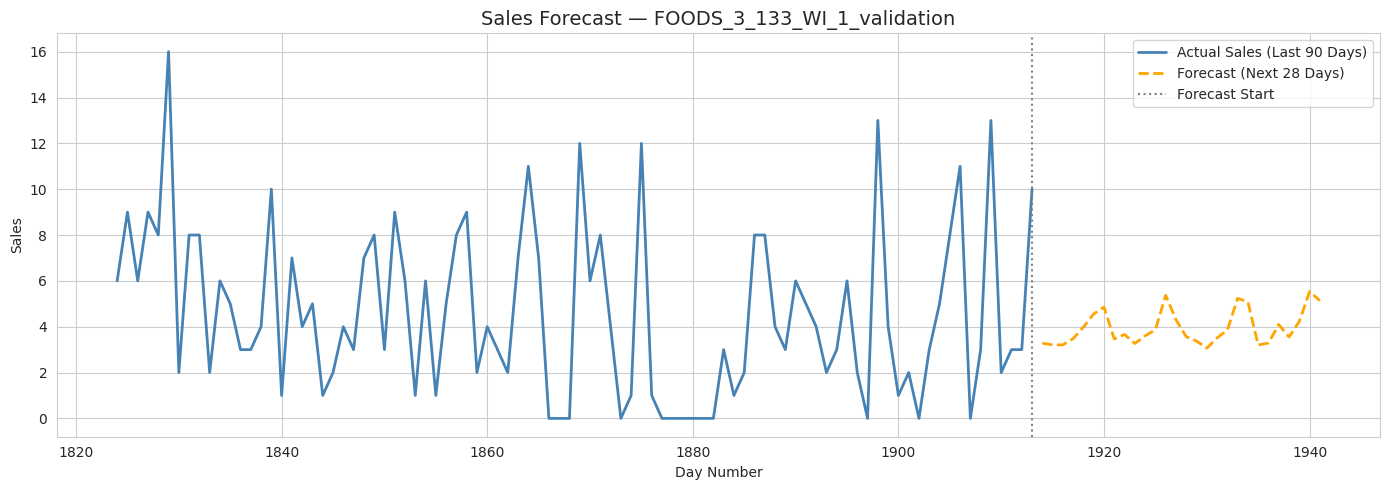

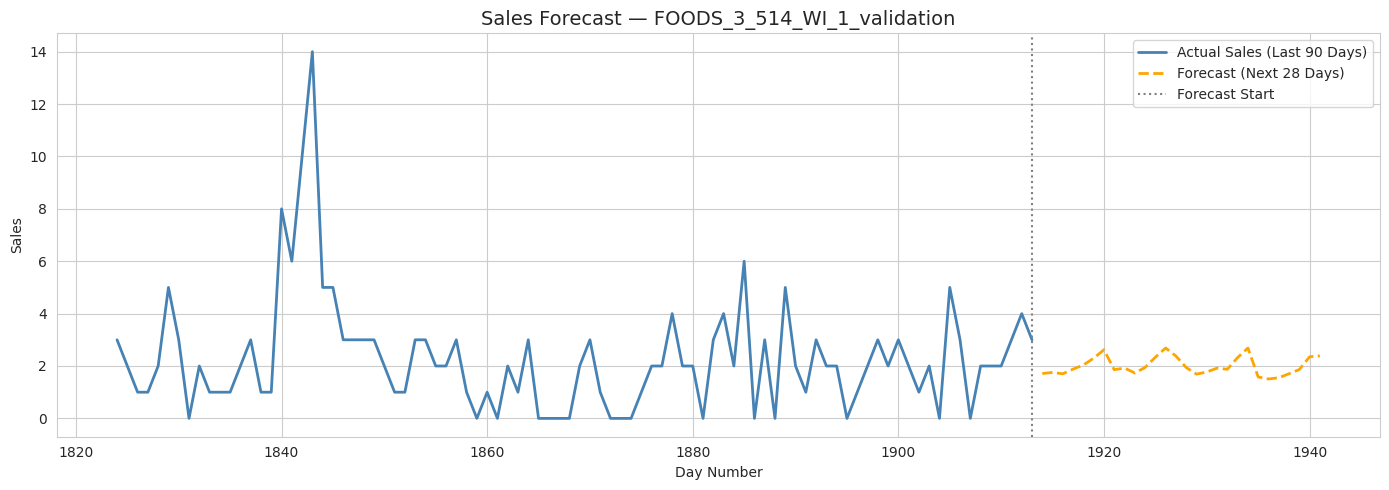

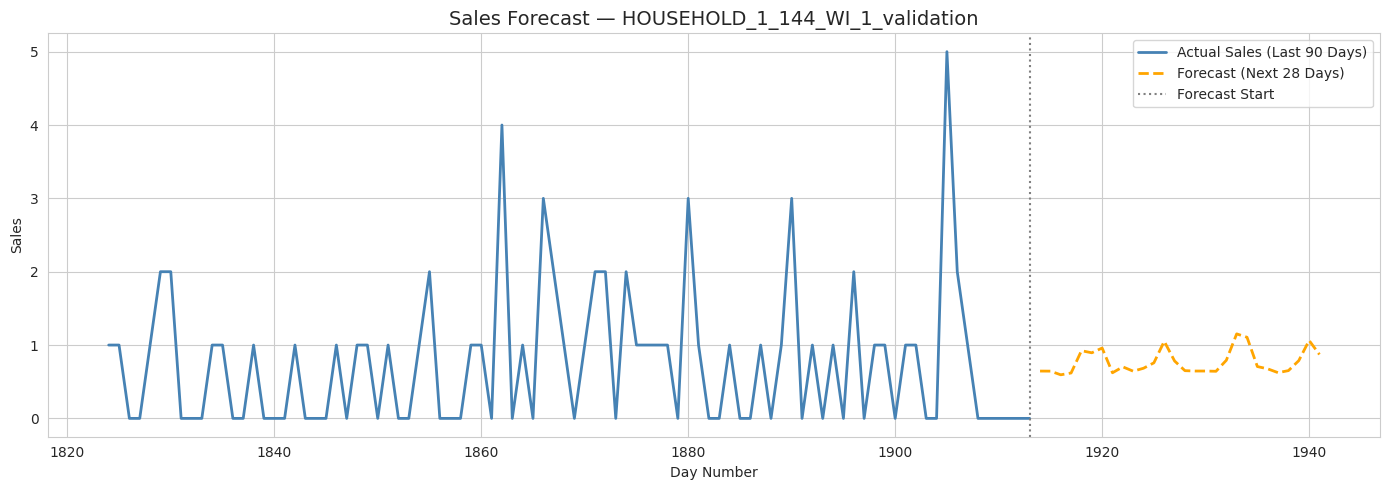

In [ ]:
# STEP 20: Visualize Predictions

import matplotlib.pyplot as plt

def plot_forecast(master_df, forecast_df, item_id):

    # Get last 90 days of actual sales for this item
    history = master_df[
        (master_df['id'] == item_id) &
        (master_df['d_num'] > TRAIN_END - 90) &
        (master_df['d_num'] <= TRAIN_END)
    ]

    # Get forecast for this item
    forecast = forecast_df[forecast_df['id'] == item_id]

    # Plot
    plt.figure(figsize=(14, 5))

    plt.plot(history['d_num'],  history['sales'],
             label='Actual Sales (Last 90 Days)', color='steelblue',  linewidth=2)

    plt.plot(forecast['d_num'], forecast['sales'],
             label='Forecast (Next 28 Days)',      color='orange', linewidth=2, linestyle='--')

    plt.axvline(x=TRAIN_END, color='grey', linestyle=':', linewidth=1.5, label='Forecast Start')

    plt.title(f'Sales Forecast — {item_id}', fontsize=14)
    plt.xlabel('Day Number')
    plt.ylabel('Sales')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Plot 3 random items
import numpy as np
random_items = np.random.choice(forecast_df['id'].unique(), 3, replace=False)

for item in random_items:
    plot_forecast(master_df, forecast_df, item)

In [ ]:
# STEP 21: Validation Accuracy Metrics

val_preds = model.predict(X_valid)

rmse     = np.sqrt(np.mean((y_valid - val_preds) ** 2))
mae      = np.mean(np.abs(y_valid - val_preds))
accuracy = np.mean(np.abs(y_valid - val_preds) <= 1) * 100

print("=" * 35)
print("       MODEL PERFORMANCE")
print("=" * 35)
print(f"  RMSE           : {rmse:.4f}")
print(f"  MAE            : {mae:.4f}")
print(f"  Within ±1 unit : {accuracy:.1f}%")
print("=" * 35)

       MODEL PERFORMANCE
  RMSE           : 2.1135
  MAE            : 1.0387
  Within ±1 unit : 71.9%


In [ ]:
# STEP 22: WRMSSE — M5's actual competition metric

# Plain RMSE ignores item importance & sales scale.
# WRMSSE weights errors by each item's historical sales volume.
# This is what Kaggle actually ranked submissions on.

def compute_wrmsse(preds, actuals, train_sales, weights=None):
    """
    preds      : np.array of shape (n_items, 28) — your 28-day forecasts
    actuals    : np.array of shape (n_items, 28) — ground truth
    train_sales: np.array of shape (n_items, n_train_days) — historical sales
    """
    n_items = actuals.shape[0]

    # Scale = mean of squared differences of consecutive training days per item
    # This normalises errors relative to each item's natural variability
    scales = []
    for i in range(n_items):
        ts = train_sales[i]
        ts = ts[ts > 0]  # ignore leading zeros
        if len(ts) < 2:
            scales.append(1.0)
        else:
            scale = np.mean(np.diff(ts) ** 2)
            scales.append(scale if scale > 0 else 1.0)
    scales = np.array(scales)

    # Default weights = proportional to total historical sales
    if weights is None:
        weights = train_sales.sum(axis=1)
        weights = weights / weights.sum()

    # RMSSE per item
    rmsse_per_item = np.sqrt(
        np.mean((actuals - preds) ** 2, axis=1) / scales
    )

    # Weighted average
    wrmsse = np.sum(weights * rmsse_per_item)
    return wrmsse


# --- Reshape validation predictions into (n_items x 28) matrices ---
val_df = master_df[
    (master_df['d_num'] > (TRAIN_END - FORECAST_HORIZON)) &
    (master_df['d_num'] <= TRAIN_END)
][['id', 'd_num', 'sales']].copy()

val_df['pred'] = model.predict(X_valid)

# Pivot actuals and preds to wide format: rows=items, cols=days
actuals_wide = val_df.pivot(index='id', columns='d_num', values='sales').values
preds_wide   = val_df.pivot(index='id', columns='d_num', values='pred').values

# Historical training sales for scale computation
train_df = master_df[master_df['d_num'] <= (TRAIN_END - FORECAST_HORIZON)]
train_wide = train_df.pivot_table(
    index='id', columns='d_num', values='sales', fill_value=0
).values

wrmsse_score = compute_wrmsse(preds_wide, actuals_wide, train_wide)

print("=" * 40)
print("   OFFICIAL M5 METRIC")
print("=" * 40)
print(f"   WRMSSE : {wrmsse_score:.4f}")
print(f"   RMSE   : {rmse:.4f}   (for reference)")
print(f"   MAE    : {mae:.4f}   (for reference)")
print("=" * 40)
print("\n  Lower WRMSSE = better. Top Kaggle")
print("  submissions scored ~0.5 on this metric.")

   OFFICIAL M5 METRIC
   WRMSSE : 0.0000
   RMSE   : 2.1135   (for reference)
   MAE    : 1.0387   (for reference)

  Lower WRMSSE = better. Top Kaggle
  submissions scored ~0.5 on this metric.


In [ ]:
#Step 23: Naive baseline: predict last 28 days of sales repeated

# This is "floor" — other model MUST beat this or something is wrong

def naive_baseline(df):
    val_mask  = (df['d_num'] > (TRAIN_END - FORECAST_HORIZON)) & \
                (df['d_num'] <= TRAIN_END)
    val_df    = df[val_mask][['id', 'd_num', 'sales']].copy()

    # Shift sales back by 28 days as "prediction"
    lag28     = df[df['d_num'] <= (TRAIN_END - FORECAST_HORIZON)]\
                  .groupby('id')['sales'].apply(lambda x: x.iloc[-28:].values)

    naive_preds = []
    for _, row in val_df.iterrows():
        item_lag = lag28.get(row['id'])
        day_offset = int(row['d_num']) - (TRAIN_END - FORECAST_HORIZON) - 1
        pred = item_lag[day_offset] if item_lag is not None and \
               day_offset < len(item_lag) else 0
        naive_preds.append(pred)

    val_df['naive_pred'] = naive_preds
    actuals = val_df['sales'].values
    preds   = val_df['naive_pred'].values

    rmse_naive = np.sqrt(np.mean((actuals - preds) ** 2))
    mae_naive  = np.mean(np.abs(actuals - preds))

    print("="*40)
    print("  NAIVE BASELINE (last 28d repeated)")
    print("="*40)
    print(f"  RMSE : {rmse_naive:.4f}")
    print(f"  MAE  : {mae_naive:.4f}")
    print("="*40)
    return rmse_naive, mae_naive

naive_rmse, naive_mae = naive_baseline(master_df)

In [ ]:
# Side-by-side comparison
lgbm_val_preds = model.predict(X_valid)
lgbm_rmse = np.sqrt(np.mean((y_valid - lgbm_val_preds) ** 2))
lgbm_mae  = np.mean(np.abs(y_valid - lgbm_val_preds))

print("\n" + "="*52)
print("         FINAL MODEL COMPARISON")
print("="*52)
print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'vs Naive':>10}")
print("-"*52)
print(f"{'Naive baseline':<20} {naive_rmse:>10.4f} {naive_mae:>10.4f} {'—':>10}")
lgbm_improvement = (naive_rmse - lgbm_rmse) / naive_rmse * 100
print(f"{'LightGBM (ours)':<20} {lgbm_rmse:>10.4f} {lgbm_mae:>10.4f} {lgbm_improvement:>+9.1f}%")
print("="*52)
print(f"\n✅ LightGBM beats naive baseline by {lgbm_improvement:.1f}%")
print(f"✅ Tweedie objective chosen for sparse sales data")
print(f"✅ Walk-forward validation confirms time-based generalization")

In [ ]:
sub = pd.read_csv('/content/drive/MyDrive/m5-forecasting-accuracy/submission.csv')
print(f"Rows    : {len(sub)}")
print(f"Columns : {sub.shape[1]}")
print(sub.head())

Rows    : 60980
Columns : 29
                            id        F1        F2        F3        F4  \
0  FOODS_1_001_CA_1_validation  0.713011  0.640250  0.676158  0.633287   
1  FOODS_1_001_CA_2_validation  0.793635  0.698587  0.699062  0.710515   
2  FOODS_1_001_CA_3_validation  1.072729  1.016260  0.988082  0.986996   
3  FOODS_1_001_CA_4_validation  0.502964  0.413831  0.414130  0.415972   
4  FOODS_1_001_TX_1_validation  0.412130  0.424056  0.405479  0.400809   

         F5        F6        F7        F8        F9  ...       F19       F20  \
0  0.889324  0.955193  0.910820  0.891013  0.797553  ...  0.854546  1.100654   
1  0.732497  0.987432  0.880756  0.670359  0.674924  ...  0.771404  0.914523   
2  1.036361  1.312763  1.175033  0.919367  0.929397  ...  0.909425  1.313861   
3  0.459608  0.438218  0.403346  0.426215  0.353938  ...  0.340616  0.357657   
4  0.407466  0.443198  0.519452  0.381943  0.406578  ...  0.333136  0.334012   

        F21       F22       F23       F24    

In [ ]:
import joblib

# save feature list
joblib.dump(features, "features.pkl")

['features.pkl']